### What this notebook does

We take the best model so far (the XGBoost tuned in XGBoost_baseline) and check two things: where it predicts badly, and whether some of the data is hurting it.

The main idea is out-of-fold prediction. We split the genes into three groups, train on two and predict the third, then rotate, so every siRNA is predicted by a model that never saw its gene.

Once every row has a prediction we keep one table and slice it different ways: by gene, by patent, by region of the mRNA, by cell type. We score with Spearman, which only checks that the order is right (strong siRNAs above weak ones), not the exact number.

### Building the data and the predictions

We build the feature table through the base_pipeline: clean the data, line each siRNA up against its mRNA etc. We also drop siRNAs whose guide does not match the mRNA (more than 5 mismatches), since those would only add noise.

Then we run the out-of-fold prediction and keep one table called diag, with the true inhibition, the predicted inhibition, and every label we might group by

In [45]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

repo_root = Path.cwd().parent if Path.cwd().name == "classical_ml" else Path.cwd()
sys.path.insert(0, str(repo_root))

from classical_ml.random_forest.config import RandomForestExperimentConfig
from classical_ml.random_forest.data import RandomForestDataBuilder
from classical_ml.random_forest.metrics import compute_regression_metrics
from utils.splitter import GroupKFoldLeakPerGroup

sns.set_theme(style="whitegrid")

data_dir = Path("/Users/alinalapkovskaya/Documents/TUM/ML4RG/siRNA_project/data")
cmsirna_tsv = data_dir/"CMsiRNA_data_update.tsv"
historic_csv = data_dir/"Historic_Takayuki_hueskan_ichihara.csv"

plots_dir = repo_root/"classical_ml"/"plots"
plots_dir.mkdir(parents=True, exist_ok=True)

In [46]:
# the by-gene tuned XGBoost from XGBoost_baseline
by_gene_params = {
    "n_estimators": 800,
    "max_depth": 4,
    "learning_rate": 0.159,
    "subsample": 0.881,
    "colsample_bytree": 0.782,
    "min_child_weight": 4,
    "reg_lambda": 0.834,
    "reg_alpha": 1.43,
    "gamma": 0.075,
}


def make_model(params=by_gene_params):
    return XGBRegressor(tree_method="hist", n_jobs=-1, random_state=42, **params)

In [47]:
# normal cleaning (it already drops the bad rows), with mRNA alignment so we get the UTR columns
config = RandomForestExperimentConfig(
    strict_cleaning=False,
    add_mrna=True,
    fetch_missing_mrna=False,
    use_normalized_conditions=False,
)
builder = RandomForestDataBuilder(config)
prepared = builder.build_from_merged_sources(cmsirna_tsv, historic_csv)

enriched = prepared.enriched_df.reset_index(drop=True)
X, groups, y = np.asarray(prepared.X), np.asarray(prepared.groups), np.asarray(prepared.y, dtype=float)

# keep only rows that actually have a measured inhibition
labeled = np.isnan(y) == False
X, groups, y = X[labeled], groups[labeled], y[labeled]
meta = enriched.loc[labeled].reset_index(drop=True)

# binding QC: edit_distance counts mismatches between the guide and the mRNA. above 5 mismmatches 
# we drop those rows 
max_edit_distance = 5
edit = pd.to_numeric(meta["edit_distance"], errors="coerce").to_numpy()
keep = edit <= max_edit_distance
print("removing", int((edit > max_edit_distance).sum()), "rows with edit distance > 5")
X, groups, y = X[keep], groups[keep], y[keep]
meta = meta.loc[keep].reset_index(drop=True)
print(X.shape, y.shape, np.unique(groups).size, "genes")

loaded 3515 historic rows
merged 43153 CMsiRNA and 3515 historic rows into 46668
Running qc and data cleaning
dropped 5756 rows (in-vivo 4233, mM 565, conc>200 797, cell 115, inhibition 102)
dropped 1749 rows with NaN concentration
dropped 2198 rows with a missing or >25 nt strand
imputed 6091 missing time rows (median 24.0h at or below 10 nM, 48.0h above)
dropped 5 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Sense_strand']
Mapping mRNA structural profiles
Error reading reference dataset: [Errno 2] No such file or directory: '/home/larsena8/software/fennec/src/fennec/support_files/train_data_v1.1.0_N=27742.csv'
Loaded 47 gene sequences from local cache
Loaded 0 gene sequences from reference CSV
Building gene -> mRNA mapping for 54 genes...
[1/54] Processing CTNNB1...
  Found in local cache (3074 bp)
[2/54] Processing INHBE...
  Found in local cache (2460 bp)
[3/

In [48]:
def oof_predictions(X, y, groups, params, drop_from_train=None, n_splits=3, leak_n=0):
    #predict each gene with a model trained on the other genes
    #leak_n=0, so its a clean grouped split; drop_from_train removes rows from training only.
    splitter = GroupKFoldLeakPerGroup(n_splits=n_splits, leak_n=leak_n, random_state=42)
    pred = np.full(len(y), np.nan)
    fold = np.full(len(y), -1)
    for k, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups)):
        if drop_from_train is not None:
            keep = drop_from_train[train_idx] == False   #drop these from training only
            train_idx = train_idx[keep]
        model = make_model(params)
        model.fit(X[train_idx], y[train_idx])
        pred[test_idx] = model.predict(X[test_idx])
        fold[test_idx] = k
    return pred, fold


y_pred, fold = oof_predictions(X, y, groups, by_gene_params)
scored = np.isnan(y_pred) == False   # leaked rows get no prediction;with leak_n=0 every row is scored
print(scored.sum(), "of", len(y_pred), "rows scored out of fold")
print("overall out-of-fold metrics:", compute_regression_metrics(y[scored], y_pred[scored]))

35444 of 35444 rows scored out of fold
overall out-of-fold metrics: {'pearson': 0.38496776955032674, 'spearman': 0.3852017302376373, 'rmse': 33.14864805426861, 'mae': 26.08636500781656}


In [49]:
# CDS region per siRNA, reusing the UTR columns (mRNA_five_prime/mRNA_three_prime
# from find_utr_regions). the CDS starts where the 5'UTR ends and ends where the 3'UTR begins.
def cds_region(five_prime, three_prime, mrna_len, target_site_pct):
    five_missing = not isinstance(five_prime, str)
    three_missing = not isinstance(three_prime, str)
    if five_missing and three_missing:
        return "unknown"   # no ORF(open reading frame) found (e.g. EGFP (with no human mRNA))
    if np.isnan(target_site_pct) or np.isnan(mrna_len) or mrna_len <= 0:
        return "unknown"
    cds_start = 0 if five_missing else len(five_prime)
    cds_end = mrna_len if three_missing else mrna_len - len(three_prime)
    start = target_site_pct * mrna_len   #this recovers the alignment start nucleotide
    if start < cds_start:
        return "5'UTR"
    if start < cds_end:
        return "CDS"
    return "3'UTR"


# one diagnostic frame: prediction plus every key we want to slice by
diag = pd.DataFrame({
    "gene": groups,
    "patent": meta["patent_ID"].values,
    "cell_type": meta["Cell_Type"].values,
    "concentration_nM": pd.to_numeric(meta["Concentration_nM"], errors="coerce").values,
    "target_site_pct": pd.to_numeric(meta["target_site_pct"], errors="coerce").values,
    "mrna_len": meta["mRNA"].astype(str).str.len().where(meta["mRNA"].notna()).values,
    "edit_distance": pd.to_numeric(meta["edit_distance"], errors="coerce").values,
    "label_sd": pd.to_numeric(meta["SD"], errors="coerce").values,
    "y_true": y,
    "y_pred": y_pred,
    "fold": fold,
})
diag["residual"] = diag["y_true"] - diag["y_pred"]
diag["cds_region"] = [
    cds_region(f, t, l, pct)
    for f, t, l, pct in zip(
        meta["mRNA_five_prime"], meta["mRNA_three_prime"],
        diag["mrna_len"], diag["target_site_pct"],
    )
]
region_order = ["5'UTR", "CDS", "3'UTR", "unknown"]
diag["cds_region"] = pd.Categorical(diag["cds_region"], categories=region_order, ordered=True)
print(diag["cds_region"].value_counts().reindex(region_order))
diag.head()

cds_region
5'UTR       1253
CDS        20162
3'UTR      12983
unknown     1046
Name: count, dtype: int64


,gene,patent,cell_type,concentration_nM,target_site_pct,mrna_len,edit_distance,label_sd,y_true,y_pred,fold,residual,cds_region
0,CTNNB1,CN107365771B,Hela,100.0,0.236825,3074,0.0,NaN,88.0,99.710129,1,-11.710129,CDS
1,CTNNB1,CN107365771B,Hela,100.0,0.255693,3074,0.0,NaN,90.0,57.328476,1,32.671524,CDS
2,CTNNB1,CN107365771B,Hela,100.0,0.431034,3074,0.0,NaN,90.0,64.561096,1,25.438904,CDS
3,CTNNB1,CN107365771B,Hela,100.0,0.445999,3074,0.0,NaN,89.0,54.115921,1,34.884079,CDS
4,CTNNB1,CN107365771B,Hela,100.0,0.564736,3074,0.0,NaN,87.0,59.454456,1,27.545544,CDS


In [28]:
# sanity check: most siRNAs should target CDS or 3'UTR, few the 5'UTR, and the boundaries
share = (diag["cds_region"].value_counts(normalize=True) * 100).round(1)
print("region share (%):")
print(share.reindex(region_order))

# boundaries read straight mRNA_five_prime/mRNA_three_prime columns
rows = []
for g in ["CTNNB1", "PCSK9", "AGT", "DBI"]:
    sub = meta.loc[groups == g]
    if sub.empty:
        continue
    r = sub.iloc[0]
    five_len = len(r["mRNA_five_prime"]) if isinstance(r["mRNA_five_prime"], str) else 0
    n = len(r["mRNA"]) if isinstance(r["mRNA"], str) else 0
    three_len = len(r["mRNA_three_prime"]) if isinstance(r["mRNA_three_prime"], str) else 0
    rows.append((g, five_len, n - three_len, n))
check = pd.DataFrame(rows, columns=["gene", "cds_start", "cds_end", "mrna_len"])
check

region share (%):
cds_region
5'UTR       3.5
CDS        56.9
3'UTR      36.6
unknown     3.0
Name: proportion, dtype: float64


,gene,cds_start,cds_end,mrna_len
0,CTNNB1,214,2377,3074
1,PCSK9,290,1868,3136
2,AGT,67,1498,2116
3,DBI,75,3559,3784


### Spearman per gene

For each gene on its own, we check whether the model ranks its siRNAs correctly. We compute Spearman inside each gene and sort worst to best, so the genes the model struggles with come first.

We skip genes with too few points, or where the inhibition barely varies, because a correlation on a few near-identical numbers is meaningless.

In [29]:
def spearman_by_group(frame, key, min_n=10):
    #within-group ranking quality, skip groups that are too small or flat to trust
    rows = []
    for name, g in frame.groupby(key, observed=True):
        g = g.dropna(subset=["y_true", "y_pred"])
        if len(g) < min_n:
            continue
        m = compute_regression_metrics(g["y_true"], g["y_pred"])
        rows.append({
            key: name,
            "n": len(g),
            "spearman": m["spearman"],
            "pearson": m["pearson"],
            "rmse": m["rmse"],
            "mean_y": g["y_true"].mean(),
            "std_y": g["y_true"].std(),
            "mean_label_sd": g["label_sd"].mean(),
        })
    out = pd.DataFrame(rows).sort_values("spearman", na_position="first").reset_index(drop=True)
    return out


by_gene = spearman_by_group(diag, "gene", min_n=15)
by_gene

,gene,n,spearman,pearson,rmse,mean_y,std_y,mean_label_sd
0,PLN,135,-0.028156,-0.044074,36.899275,50.096000,28.258452,1.576311
1,ANGPTL3,495,0.110470,0.167408,41.687127,51.696909,37.687436,2.349899
2,CTNNB1,1171,0.313804,0.296697,30.911842,68.119172,24.164170,3.217930
3,INHBE,3509,0.328098,0.321001,33.585341,27.954708,34.479471,5.851774
4,FXYD6,72,0.331559,0.321615,19.389158,72.044444,19.130654,NaN
5,SOST,75,0.345181,0.383874,13.809133,62.613333,12.537817,NaN
6,AGT,4738,0.348169,0.377931,44.794656,57.980388,34.548543,5.110087
7,MAPT,903,0.360186,0.400837,27.875769,43.199889,26.141458,10.729797
8,PCSK9,2678,0.363481,0.369917,32.889345,42.163529,33.289103,7.948704
9,ICAM-1,40,0.375969,0.334874,24.451940,28.125000,21.996722,NaN


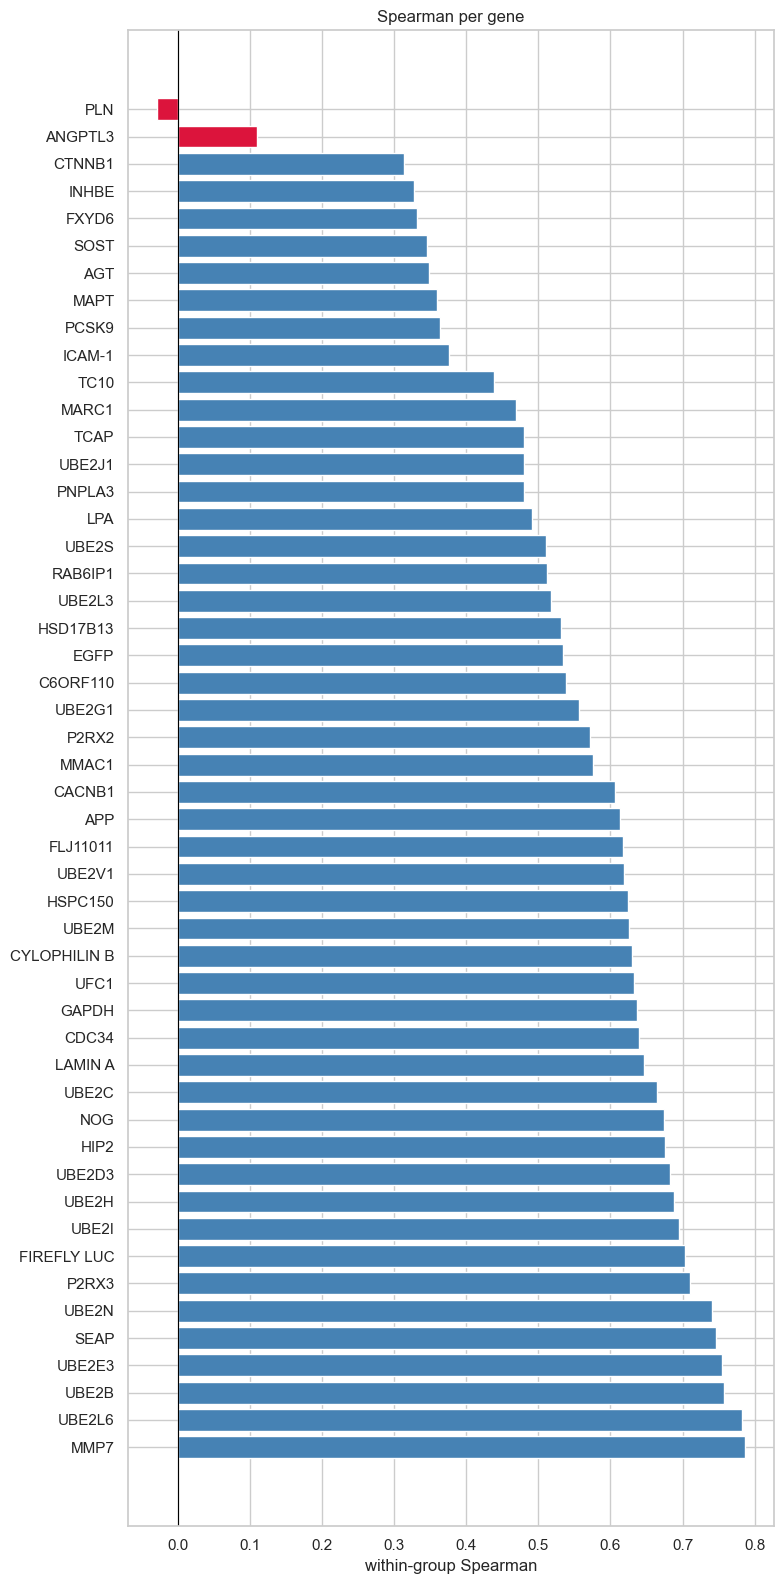

In [30]:
def plot_group_spearman(table, key, title, fname):
    # horizontal bar of per-group Spearman
    valid = table.dropna(subset=["spearman"])
    plt.figure(figsize=(8, max(3, 0.32 * len(valid))))
    colors = ["crimson" if s < 0.2 else "steelblue" for s in valid["spearman"]]
    plt.barh(valid[key].astype(str), valid["spearman"], color=colors)
    plt.axvline(0, color="black", lw=0.8)
    plt.xlabel("within-group Spearman")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(plots_dir / fname, dpi=150)
    plt.show()


plot_group_spearman(by_gene, "gene", "Spearman per gene", "spearman_by_gene.png")

In [31]:

# the binding QC (edit distance <= 5) removes the worst ones and leaves even fewer. On so few rows any
# Spearman is noise
dbi = diag[diag["gene"] == "DBI"]
dbi_scored = dbi.dropna(subset=["y_pred"])
print(f"DBI rows surviving cleaning + binding QC: {len(dbi)}; scored out-of-fold: {len(dbi_scored)}")
print("DBI metrics (low n, indicative only):", compute_regression_metrics(dbi_scored["y_true"], dbi_scored["y_pred"]))
display(dbi[["concentration_nM", "cell_type", "cds_region", "edit_distance", "y_true", "y_pred", "fold"]])

DBI rows surviving cleaning + binding QC: 7; scored out-of-fold: 7
DBI metrics (low n, indicative only): {'pearson': 0.49667326438986975, 'spearman': 0.22237479499833038, 'rmse': 30.04325260042548, 'mae': 23.783918047208527}


,concentration_nM,cell_type,cds_region,edit_distance,y_true,y_pred,fold
32257,100.0,HEK293 Cells,CDS,4.0,4.897233,15.702356,2
32258,100.0,HEK293 Cells,CDS,5.0,0.000000,50.701717,2
32259,100.0,HEK293 Cells,3'UTR,5.0,6.007244,3.961669,2
32260,100.0,HEK293 Cells,CDS,5.0,0.000000,41.105957,2
32261,100.0,HEK293 Cells,CDS,5.0,0.000000,41.550552,2
32262,100.0,HEK293 Cells,CDS,4.0,33.722439,42.308781,2
32263,100.0,HEK293 Cells,CDS,5.0,71.772307,60.080147,2


In [32]:
# the other three cuts of the same out-of-fold predictions
by_patent = spearman_by_group(diag, "patent", min_n=20)
#the three real regions; low_align and unknown are quality buckets
real_regions = diag[diag["cds_region"].isin(["5'UTR", "CDS", "3'UTR"])]
by_region = spearman_by_group(real_regions, "cds_region", min_n=20)
by_cell = spearman_by_group(diag, "cell_type", min_n=20)

print("worst patents")
display(by_patent.head(10))
print("CDS region")
display(by_region)
print("cell type")
display(by_cell.head(10))

worst patents


,patent,n,spearman,pearson,rmse,mean_y,std_y,mean_label_sd
0,CN112313335A,366,-0.812658,-0.744197,73.820727,95.782978,4.268011,NaN
1,US20220380773A1,170,-0.637965,-0.610900,44.189074,41.005882,31.526733,NaN
2,WO2023213284A1,48,-0.523533,-0.412771,35.885167,86.482083,11.996647,NaN
3,CN109957567B,39,-0.495437,-0.385576,38.768746,63.641026,24.854828,NaN
4,WO2023091644A2,1445,-0.131742,-0.090411,31.568289,48.121391,28.523717,NaN
5,CN117210468A,225,-0.079699,0.018958,27.134189,25.280444,18.697982,NaN
6,WO2023064530A1,135,-0.028156,-0.044074,36.899275,50.096000,28.258452,1.576311
7,CN101484588B,718,-0.027039,0.017271,38.504278,49.736769,31.673527,NaN
8,CN117106781A,20,-0.004511,0.035905,27.283196,65.312500,15.535050,NaN
9,CN113980966A,57,-0.004505,-0.039076,40.390460,83.438596,12.295495,NaN


CDS region


,cds_region,n,spearman,pearson,rmse,mean_y,std_y,mean_label_sd
0,3'UTR,12983,0.317261,0.324647,33.961640,45.346543,32.525417,8.133100
1,CDS,20162,0.379434,0.372056,33.790790,40.643342,34.541371,7.482789
2,5'UTR,1253,0.792159,0.803782,20.984099,45.932386,35.016658,8.432047


cell type


,cell_type,n,spearman,pearson,rmse,mean_y,std_y,mean_label_sd
0,Primary mouse hepatocytes,316,-0.181716,-0.163830,70.777199,25.005696,51.883542,10.261047
1,Primary Macaque Hepatocytes,22,-0.127227,-0.177089,42.231774,93.389091,4.227497,NaN
2,Hepa1-6,139,-0.009614,-0.024799,36.488327,51.316259,28.742585,1.576311
3,Primary human hepatocytes,2944,0.078646,0.155222,32.062133,50.880149,29.108101,16.392520
4,Non-human hepatocytes,190,0.081127,0.001390,32.048395,22.762105,18.441351,NaN
5,Human iPSC-derived cortical neurons,205,0.081923,0.160542,34.814179,42.600976,32.076117,5.915610
6,Primary Cynomolgus Monkey Hepatocytes,4268,0.142996,0.124055,37.660711,34.462720,30.574557,9.730493
7,Hela,1906,0.250701,0.236511,35.771375,41.380367,33.481523,8.610329
8,Hep3B,11967,0.320255,0.325020,36.748295,42.360623,36.233379,6.839627
9,T24 Cells,76,0.360526,0.355428,22.475591,33.131579,22.397823,NaN


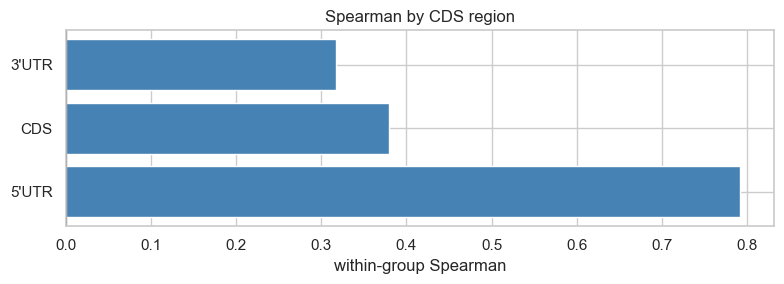

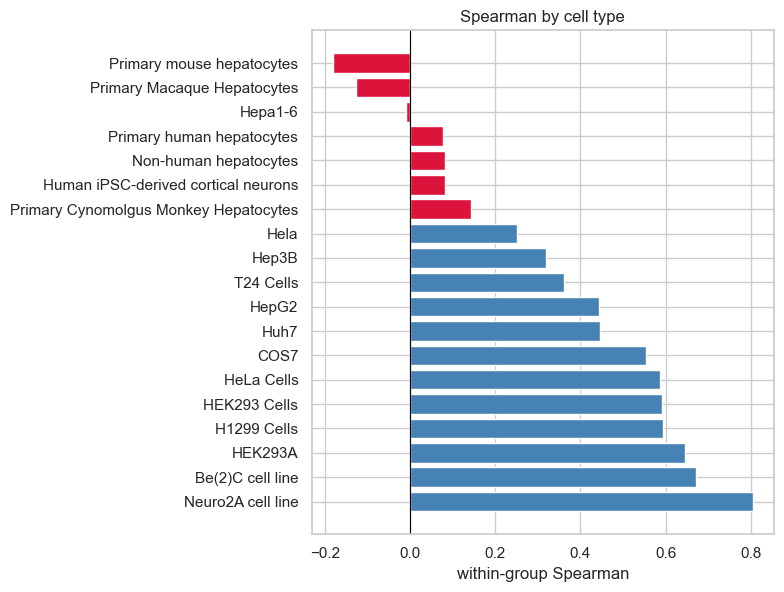

In [33]:
plot_group_spearman(by_region, "cds_region", "Spearman by CDS region", "spearman_by_region.png")
plot_group_spearman(by_cell, "cell_type", "Spearman by cell type", "spearman_by_cell.png")

### Within-gene check

When we group by region or cell type, each group mixes many genes. A high score there can mean two things: ranking siRNAs correctly inside a gene, or just getting the gene averages right. Only the first is what we want.

So for those cuts we also compute a within-gene version: we subtract each gene's own average from the true and predicted values, which removes the "between-gene part" and leaves the hard "within-gene ranking".

In [34]:
# the pooled region/cell numbers mix two things: ranking siRNAs inside a gene, and ranking whole
# genes against each other. subtracting each gene's mean leaves only the within-gene part.
def within_gene_spearman(frame, key, min_n=20):
    f = frame.dropna(subset=["y_true", "y_pred"]).copy()
    f["yt_centered"] = f["y_true"] - f.groupby("gene")["y_true"].transform("mean")
    f["yp_centered"] = f["y_pred"] - f.groupby("gene")["y_pred"].transform("mean")
    rows = []
    for name, g in f.groupby(key, observed=True):
        if len(g) < min_n or g["gene"].nunique() < 2:
            continue
        rows.append({
            key: name,
            "n": len(g),
            "n_genes": g["gene"].nunique(),
            "pooled_spearman": compute_regression_metrics(g["y_true"], g["y_pred"])["spearman"],
            "within_gene_spearman": compute_regression_metrics(g["yt_centered"], g["yp_centered"])["spearman"],
        })
    return pd.DataFrame(rows)


print("CDS region: pooled vs within-gene")
display(within_gene_spearman(real_regions, "cds_region", min_n=20))
print("cell type: pooled vs within-gene (worst pooled first)")
display(within_gene_spearman(diag, "cell_type", min_n=30).sort_values("pooled_spearman"))

CDS region: pooled vs within-gene


,cds_region,n,n_genes,pooled_spearman,within_gene_spearman
0,5'UTR,1253,37,0.792159,0.489731
1,CDS,20162,24,0.379434,0.441237
2,3'UTR,12983,44,0.317261,0.445999


cell type: pooled vs within-gene (worst pooled first)


,cell_type,n,n_genes,pooled_spearman,within_gene_spearman
13,Primary mouse hepatocytes,316,4,-0.181716,0.080448
9,Hepa1-6,139,2,-0.009614,-0.026552
12,Primary human hepatocytes,2944,4,0.078646,0.058821
11,Primary Cynomolgus Monkey Hepatocytes,4268,6,0.142996,0.360568
6,Hela,1906,3,0.250701,0.231145
7,Hep3B,11967,8,0.320255,0.421798
14,T24 Cells,76,2,0.360526,0.452425
8,HepG2,1634,3,0.444317,0.301731
10,Huh7,1569,4,0.446770,0.417932
1,COS7,3760,2,0.553016,0.636095


### Scatter plots


The scatter plots colour predicted against actual by region, by edit distance, and by gene, which is where a shifted or noisy group gives itself away.

In [35]:
# triage table for the weak genes: is it noise, no variance, or shift
# nothing in this dataset drops below about 0.33
weak_threshold = 0.45
weak_genes = by_gene[by_gene["spearman"] < weak_threshold]["gene"].tolist()
if not weak_genes:
    weak_genes = by_gene.dropna(subset=["spearman"]).head(6)["gene"].tolist()
print("weak genes:", weak_genes)

triage = by_gene[by_gene["gene"].isin(weak_genes)][["gene", "n", "spearman", "std_y", "mean_label_sd"]].copy()
# how far each weak gene's concentration sits from the dataset median, a shift hint
global_conc = np.log10(diag["concentration_nM"].replace(0, np.nan)).median()
conc_shift = (
    diag[diag["gene"].isin(weak_genes)]
    .assign(log_conc=lambda d: np.log10(d["concentration_nM"].replace(0, np.nan)))
    .groupby("gene")["log_conc"].median()
    .sub(global_conc)
    .rename("log_conc_vs_global")
)
triage = triage.merge(conc_shift, on="gene", how="left").sort_values("spearman")
triage

weak genes: ['PLN', 'ANGPTL3', 'CTNNB1', 'INHBE', 'FXYD6', 'SOST', 'AGT', 'MAPT', 'PCSK9', 'ICAM-1', 'TC10']


,gene,n,spearman,std_y,mean_label_sd,log_conc_vs_global
0,PLN,135,-0.028156,28.258452,1.576311,0.00000
1,ANGPTL3,495,0.110470,37.687436,2.349899,0.00000
2,CTNNB1,1171,0.313804,24.164170,3.217930,-1.00000
3,INHBE,3509,0.328098,34.479471,5.851774,-1.00000
4,FXYD6,72,0.331559,19.130654,NaN,0.69897
5,SOST,75,0.345181,12.537817,NaN,0.69897
6,AGT,4738,0.348169,34.548543,5.110087,-1.00000
7,MAPT,903,0.360186,26.141458,10.729797,-1.00000
8,PCSK9,2678,0.363481,33.289103,7.948704,0.00000
9,ICAM-1,40,0.375969,21.996722,NaN,1.00000


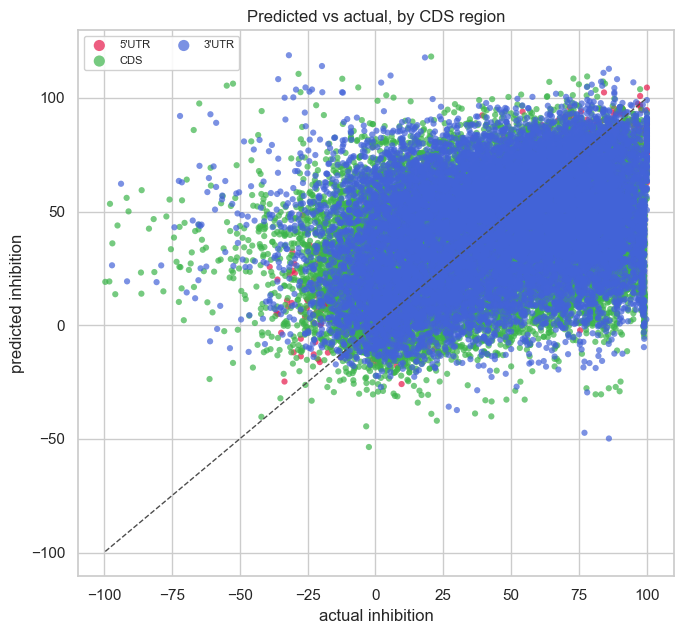

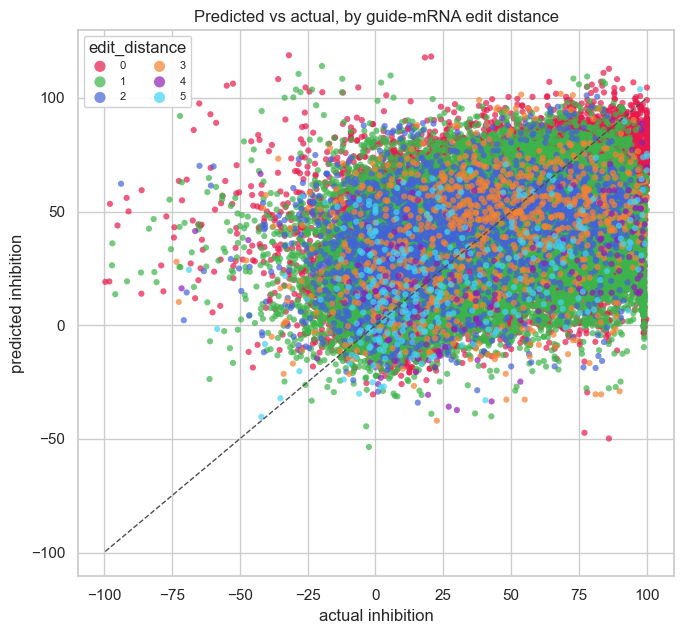

In [36]:
distinct_colors = [
    "#e6194B", "#3cb44b", "#4363d8", "#f58231", "#911eb4", "#42d4f4",
    "#f032e6", "#bfef45", "#fabed4", "#469990", "#9A6324", "#800000",
    "#808000", "#000075", "#a9a9a9", "#000000",
]


def plot_pred_vs_actual(frame, color_key, title, fname, log_color=False, discrete=False):
    # predicted vs actual, one color per category. discrete=True labels a few-valued number
    # (like edit distance) as categories instead of a continuous colorbar.
    plt.figure(figsize=(7, 6.5))
    c = frame[color_key]
    if log_color:
        c = np.log10(pd.to_numeric(c, errors="coerce").replace(0, np.nan))

    is_continuous = pd.api.types.is_numeric_dtype(c) and not discrete
    if is_continuous:
        sc = plt.scatter(frame["y_true"], frame["y_pred"], c=c, cmap="viridis", s=8, alpha=0.4)
        plt.colorbar(sc, label=("log10 " if log_color else "") + color_key)
    else:
        if discrete:
            pairs = [(v, frame[frame[color_key] == v]) for v in sorted(pd.unique(frame[color_key].dropna()))]
        else:
            pairs = list(frame.groupby(color_key, observed=True))
        for i, (name, g) in enumerate(pairs):
            label = f"{name:g}" if discrete else str(name)
            plt.scatter(g["y_true"], g["y_pred"], s=20, alpha=0.7,
                        color=distinct_colors[i % len(distinct_colors)],
                        edgecolors="none", label=label)
        plt.legend(fontsize=8, markerscale=1.8, ncol=2, framealpha=0.9,
                   title=color_key if discrete else None)
    lims = [frame["y_true"].min(), frame["y_true"].max()]
    plt.plot(lims, lims, "--", color="0.3", lw=1)
    plt.xlabel("actual inhibition")
    plt.ylabel("predicted inhibition")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(plots_dir / fname, dpi=150)
    plt.show()


plot_pred_vs_actual(real_regions, "cds_region", "Predicted vs actual, by CDS region", "scatter_by_region.png")
plot_pred_vs_actual(diag, "edit_distance", "Predicted vs actual, by guide-mRNA edit distance", "scatter_by_editdistance.png", discrete=True)

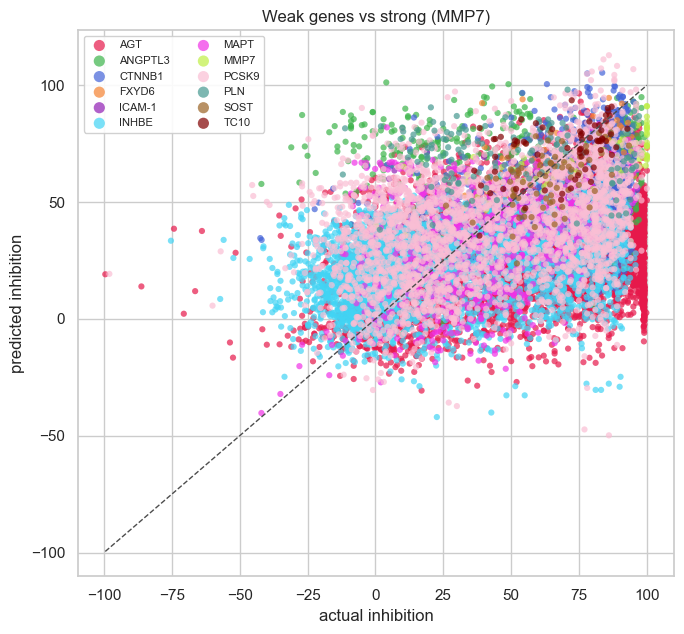

In [37]:
#zoom on the weak genes against a strong one for contrast
strong_gene = by_gene.dropna(subset=["spearman"]).iloc[-1]["gene"]
focus = diag[diag["gene"].isin(weak_genes + [strong_gene])]
plot_pred_vs_actual(focus, "gene", f"Weak genes vs strong ({strong_gene})", "scatter_weak_vs_strong.png")

### Removing noisy points

We flag rows that look unreliable: the lab reported a wide spread for that measurement, and the model already strongly disagrees with it. We drop those from training only, never from the test, retrain, and see if the rest improves. Dropping from training only, and scoring on the same rows as before, keeps the comparison fair.

In [38]:
# poison candidates: the label is unreliable (high SD) and the model already disagrees (big residual)
sd_cut = diag["label_sd"].quantile(0.75)
res_cut = diag["residual"].abs().quantile(0.90)
poison = (diag["label_sd"] > sd_cut) & (diag["residual"].abs() > res_cut)
poison = poison.fillna(False).to_numpy()
print("flagged", poison.sum(), "poison rows of", len(diag))

y_pred_clean, _ = oof_predictions(X, y, groups, by_gene_params, drop_from_train=poison)

# compare on the same rows: not poison, and predicted in both runs
comparable = (poison == False) & (np.isnan(y_pred) == False) & (np.isnan(y_pred_clean) == False)
base = compute_regression_metrics(y[comparable], y_pred[comparable])
clean = compute_regression_metrics(y[comparable], y_pred_clean[comparable])
pd.DataFrame({"baseline": base, "poison_removed": clean}).T

flagged 415 poison rows of 35444


,pearson,spearman,rmse,mae
baseline,0.406965,0.404591,32.303632,25.517992
poison_removed,0.422169,0.419075,31.941639,25.279924


In [39]:
# did removing poison help the weak genes specifically?
diag_clean = diag.copy()
diag_clean["y_pred"] = y_pred_clean
after = spearman_by_group(diag_clean[comparable], "gene", min_n=15)[["gene", "spearman"]]
before = spearman_by_group(diag[comparable], "gene", min_n=15)[["gene", "spearman"]]
delta = (
    before.merge(after, on="gene", suffixes=("_before", "_after"))
    .assign(delta=lambda d: d["spearman_after"] - d["spearman_before"])
    .sort_values("delta")
)
delta

,gene,spearman_before,spearman_after,delta
7,ICAM-1,0.375969,0.209216,-0.166753
11,MARC1,0.471537,0.360776,-0.110761
34,CDC34,0.639096,0.548089,-0.091008
13,UBE2J1,0.480496,0.402429,-0.078067
39,UBE2D3,0.683054,0.608572,-0.074481
35,LAMIN A,0.646855,0.578411,-0.068444
24,MMAC1,0.575533,0.508150,-0.067384
10,TC10,0.438518,0.378193,-0.060325
47,UBE2B,0.757009,0.707190,-0.049819
40,UBE2H,0.688454,0.641284,-0.047170


### Adding the CDS region

The model already knows where each siRNA binds on the mRNA, but not where the coding part starts and ends. We hand it the region (5'UTR, CDS, or 3'UTR) as an extra feature and check whether predictions improve. We reuse the same model settings instead of re-tuning, so this is a quick indication, not the best possible result.

In [40]:
# add the CDS region as a one-hot block and re-score with the same split (params reused, not re-tuned)
region_oh = (
    pd.get_dummies(diag["cds_region"], prefix="region")
    .reindex(columns=[f"region_{r}" for r in region_order], fill_value=0)
    .astype(float)
    .values
)
X_region = np.hstack([X, region_oh])
print("feature matrix grew from", X.shape, "to", X_region.shape)

y_pred_region, _ = oof_predictions(X_region, y, groups, by_gene_params)
both = (np.isnan(y_pred) == False) & (np.isnan(y_pred_region) == False)
overall = pd.DataFrame({
    "baseline": compute_regression_metrics(y[both], y_pred[both]),
    "plus_cds_region": compute_regression_metrics(y[both], y_pred_region[both]),
}).T
overall

feature matrix grew from (35444, 1425) to (35444, 1429)


,pearson,spearman,rmse,mae
baseline,0.384968,0.385202,33.148648,26.086365
plus_cds_region,0.399276,0.399316,32.904210,25.853722


In [41]:
# where did the region feature help? per CDS region and per gene
diag_region = diag.copy()
diag_region["y_pred"] = y_pred_region

mask_real = diag["cds_region"].isin(["5'UTR", "CDS", "3'UTR"])
reg_before = spearman_by_group(diag[mask_real], "cds_region", min_n=20)[["cds_region", "spearman"]]
reg_after = spearman_by_group(diag_region[mask_real], "cds_region", min_n=20)[["cds_region", "spearman"]]
region_lift = reg_before.merge(reg_after, on="cds_region", suffixes=("_before", "_after"))
region_lift["delta"] = region_lift["spearman_after"] - region_lift["spearman_before"]
print("per-region lift")
display(region_lift)

g_before = spearman_by_group(diag, "gene", min_n=15)[["gene", "spearman"]]
g_after = spearman_by_group(diag_region, "gene", min_n=15)[["gene", "spearman"]]
gene_lift = (
    g_before.merge(g_after, on="gene", suffixes=("_before", "_after"))
    .assign(delta=lambda d: d["spearman_after"] - d["spearman_before"])
    .sort_values("delta")
)
print("per-gene lift (5 most hurt, 5 most helped)")
display(pd.concat([gene_lift.head(5), gene_lift.tail(5)]))

per-region lift


,cds_region,spearman_before,spearman_after,delta
0,3'UTR,0.317261,0.362975,0.045714
1,CDS,0.379434,0.377388,-0.002046
2,5'UTR,0.792159,0.789821,-0.002337


per-gene lift (5 most hurt, 5 most helped)


,gene,spearman_before,spearman_after,delta
45,SEAP,0.746346,0.454044,-0.292303
9,ICAM-1,0.375969,0.226408,-0.149561
49,MMP7,0.786005,0.640180,-0.145825
0,PLN,-0.028156,-0.128120,-0.099964
35,LAMIN A,0.646855,0.567015,-0.079839
24,MMAC1,0.575533,0.620241,0.044708
13,UBE2J1,0.480496,0.529071,0.048575
28,UBE2V1,0.618692,0.683042,0.064350
2,CTNNB1,0.313804,0.389644,0.075840
4,FXYD6,0.331559,0.484902,0.153343


### Removing whole groups

This is the test of whether a group should be deleted. We drop a candidate (a cell line, or a gene) from training only, keep the test rows fixed, and check whether the rest of the data is predicted any better. We score only on rows we did not remove, so the number cannot rise just because we deleted the hard cases. If the after-removal column does not beat the baseline, the group was not hurting anything and should stay.

In [42]:
#drop a group from training only, evaluate on the same clean held-out rows,
# so the score cannot rise just because we deleted hard test rows.
def try_dropping(key, value):
    drop = (diag[key] == value).to_numpy()
    y_pred_exp, _ = oof_predictions(X, y, groups, by_gene_params, drop_from_train=drop)
    keep = (drop == False) & (np.isnan(y_pred) == False) & (np.isnan(y_pred_exp) == False)
    base = compute_regression_metrics(y[keep], y_pred[keep])
    after = compute_regression_metrics(y[keep], y_pred_exp[keep])
    print("removed", key, "==", repr(value), "-> dropped", int(drop.sum()),
          "training rows, evaluated on", int(keep.sum()), "other rows")
    return pd.DataFrame({"baseline": base, "after_removal": after}).T


print("Experiment 1: remove a weak cell line from training")
display(try_dropping("cell_type", "Primary human hepatocytes"))
print("Experiment 2: remove a weak gene from training")
display(try_dropping("gene", "AGT"))

Experiment 1: remove a weak cell line from training
removed cell_type == 'Primary human hepatocytes' -> dropped 2944 training rows, evaluated on 32500 other rows


,pearson,spearman,rmse,mae
baseline,0.394654,0.398781,33.245316,26.040664
after_removal,0.397960,0.402091,33.278286,26.108213


Experiment 2: remove a weak gene from training
removed gene == 'AGT' -> dropped 4738 training rows, evaluated on 30706 other rows


,pearson,spearman,rmse,mae
baseline,0.449399,0.456396,30.963987,24.320618
after_removal,0.439330,0.447927,30.834538,24.166179


### Removing weak genes and cells (one by one)



In [ ]:
# drop a set of rows from training only, then score on the rows we kept
def score_without(drop):
    y_pred_exp, _ = oof_predictions(X, y, groups, by_gene_params, drop_from_train=drop)
    keep = (drop == False) & (np.isnan(y_pred) == False) & (np.isnan(y_pred_exp) == False)
    before = compute_regression_metrics(y[keep], y_pred[keep])["spearman"]
    after = compute_regression_metrics(y[keep], y_pred_exp[keep])["spearman"]
    return int(drop.sum()), before, after


# the worst cell types, same idea as the weak genes from the triage table
weak_cells = spearman_by_group(diag, "cell_type", min_n=20).head(6)["cell_type"].tolist()

rows = []
for g in weak_genes:
    n, before, after = score_without((diag["gene"] == g).to_numpy())
    rows.append({"removed": g, "kind": "gene", "n_dropped": n, "before": before, "after": after, "delta": after - before})
for ct in weak_cells:
    n, before, after = score_without((diag["cell_type"] == ct).to_numpy())
    rows.append({"removed": ct, "kind": "cell", "n_dropped": n, "before": before, "after": after, "delta": after - before})

sweep = pd.DataFrame(rows).sort_values("delta").reset_index(drop=True)
print("dropping each weak group on its own (negative delta = it got worse):")
display(sweep)

# now the two all-at-once tests
for label, drop in [
    ("all weak genes", diag["gene"].isin(weak_genes).to_numpy()),
    ("all weak cells", diag["cell_type"].isin(weak_cells).to_numpy()),
]:
    n, before, after = score_without(drop)
    print(label, "-> dropped", n, "rows, Spearman", round(before, 3), "to", round(after, 3),
          "(delta", round(after - before, 3), ")")

### Comparing the two datasets



In [44]:
# recover the data source
diag["source"] = np.where(meta["patent_ID"].isna().values, "historic", "CMsiRNA")
print(diag["source"].value_counts(), "\n")

# do the two sources sit on the same inhibition scale, and does the model rank each on its own?
print("inhibition by source:")
print(diag.groupby("source")["y_true"].agg(["count", "mean", "std"]).round(1))
print("\nSpearman within each source:")
display(spearman_by_group(diag, "source", min_n=20))

source
CMsiRNA     31961
historic     3483
Name: count, dtype: int64 

inhibition by source:
          count  mean   std
source                     
CMsiRNA   31961  40.7  34.0
historic   3483  64.6  21.9

Spearman within each source:


,source,n,spearman,pearson,rmse,mean_y,std_y,mean_label_sd
0,CMsiRNA,31961,0.336360,0.329179,34.456005,40.688615,33.978723,7.788767
1,historic,3483,0.631341,0.635971,16.964710,64.647422,21.905543,NaN
